In [2]:
import pytorch3d.io
import pytorch3d.ops
import pytorch3d.structures
import torch
import numpy as np
import imageio
import matplotlib.pyplot as plt

In [3]:
meshes = pytorch3d.io.load_objs_as_meshes(["data/cow.obj"])


In [4]:
# sample 10, 100, 1000, and 10000 points
points, textures = pytorch3d.ops.sample_points_from_meshes(meshes, 100, return_textures=True)
points, textures

(tensor([[[ 0.2801, -0.0654, -0.0928],
          [-0.2027, -0.5097,  0.6327],
          [ 0.0019, -0.4028, -0.0034],
          [ 0.1534,  0.2777, -0.6595],
          [-0.0810, -0.6003,  0.7633],
          [ 0.3537,  0.0144,  0.2172],
          [ 0.2560,  0.2358, -0.2718],
          [-0.1893, -0.3661,  0.9230],
          [-0.2581, -0.6905,  0.1342],
          [ 0.2922, -0.4132,  0.5161],
          [-0.3325, -0.1714,  0.7577],
          [ 0.0497,  0.3874, -0.6412],
          [ 0.2855, -0.5927,  0.6795],
          [-0.1293,  0.8858, -0.2963],
          [ 0.2930,  0.0815,  0.4138],
          [-0.3604, -0.1011,  0.5036],
          [-0.1756,  0.2919,  0.2417],
          [ 0.1807, -0.6936,  0.6890],
          [-0.2756,  0.0836,  0.5869],
          [-0.1740, -0.5251,  0.9261],
          [ 0.1019,  0.3621,  0.0257],
          [ 0.0541,  0.2429,  0.4518],
          [-0.2013,  0.5264, -0.5319],
          [-0.1639, -0.0795,  0.9516],
          [ 0.2378, -0.5280, -0.1226],
          [-0.1949, -0.73

In [5]:
pc = pytorch3d.structures.Pointclouds(points, features=textures)

In [6]:
pc

In [14]:
def get_pointcloud(meshes, sample_num):
    # sample 10, 100, 1000, and 10000 points
    points, textures = pytorch3d.ops.sample_points_from_meshes(meshes, sample_num, return_textures=True)
    points, textures
    pc = pytorch3d.structures.Pointclouds(points, features=textures)
    return pc

In [8]:
R, T = pytorch3d.renderer.look_at_view_transform(dist=2, elev=0, azim=0)
cameras = pytorch3d.renderer.PerspectiveCameras(R=R, T=T)
lights = pytorch3d.renderer.DirectionalLights()

In [9]:
rasterizer = pytorch3d.renderer.PointsRasterizer(cameras=cameras)
renderer = pytorch3d.renderer.PointsRenderer(rasterizer=rasterizer, compositor=pytorch3d.renderer.AlphaCompositor())


In [10]:
pc1 = get_pointcloud(meshes, 10)
pc2 = get_pointcloud(meshes, 100)
pc3 = get_pointcloud(meshes, 1000)
pc4 = get_pointcloud(meshes, 10000)
pc5 = get_pointcloud(meshes, 100000)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


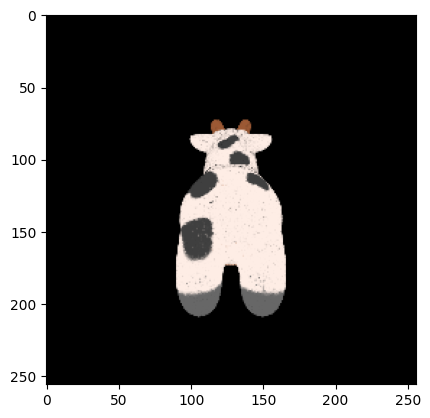

In [11]:
plt.plot(figsize=(10,10))
plt.imshow(renderer(pc5, cameras=cameras, lights=lights).squeeze(0))

In [19]:
def render_spinning_pointcloud(meshes, samples, objname):
    pc_ = get_pointcloud(meshes, samples)
    frames = []
    for azim in range(0, 360, 20):
        R, T = pytorch3d.renderer.look_at_view_transform(dist=2, elev=0, azim=azim)
        cameras = pytorch3d.renderer.PerspectiveCameras(R=R, T=T)
        lights = pytorch3d.renderer.DirectionalLights()
        frame = renderer(pc_, cameras=cameras, lights=lights).squeeze(0)
        frame = (frame * 255).numpy().astype(np.uint8)
        frames.append(frame)
    imageio.mimsave(objname + "_" + str(samples) + ".gif", frames, loop=0, duration=1000/7)

In [21]:
for samples in (10, 100, 1000, 10000, 100000):
    render_spinning_pointcloud(meshes, samples, "cow")

In [20]:
render_spinning_pointcloud(meshes, 10, "cow")

In [32]:
# Render actual model
frames_m = []
for azim in range(0, 360, 20):

    R, T = pytorch3d.renderer.look_at_view_transform(dist=2, elev=0, azim=azim)
    cameras = pytorch3d.renderer.PerspectiveCameras(R=R, T=T)
    lights = pytorch3d.renderer.DirectionalLights()
    rasterizer_m = pytorch3d.renderer.MeshRasterizer(cameras=cameras, raster_settings=pytorch3d.renderer.RasterizationSettings())
    renderer_m = pytorch3d.renderer.MeshRenderer(rasterizer=rasterizer_m, shader=pytorch3d.renderer.HardPhongShader(cameras=cameras, lights=lights))

    frame = renderer_m(meshes, cameras=cameras, lights=lights)[0, ..., :3]
    
    frame = (frame * 255).numpy().astype(np.uint8)
    frame = np.nan_to_num(frame, 255)
    
    frames_m.append(frame)
imageio.mimsave("cow_og" + ".gif", frames_m, loop=0, duration=1000/7)

In [29]:
frame[0, ..., :3]

array([[255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255